In [1]:
!pip install -q pandas matplotlib numpy tabulate

In [2]:
import math
import json
import logging

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from tabulate import tabulate

In [3]:
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s %(levelname)s %(message)s"
)

logger = logging.getLogger(__name__)

In [4]:
TOTAL_REQUESTS = 1_000_000

logger.info(
    f"Simulation Requests: {TOTAL_REQUESTS}"
)

In [5]:
"""
IMPORTANT:

These values are examples.

Update them according to:
https://platform.openai.com/pricing
"""

PRICING = {

    "gpt_4o": {

        "input_per_million": 5.00,

        "output_per_million": 15.00
    },

    "gpt_4o_mini": {

        "input_per_million": 0.15,

        "output_per_million": 0.60
    }
}

In [6]:
"""
REALISTIC ESTIMATES
BASED ON PHASE 1 + PHASE 2
"""

FEW_SHOT_INPUT_TOKENS = 2200

FEW_SHOT_OUTPUT_TOKENS = 120

FINETUNED_INPUT_TOKENS = 35

FINETUNED_OUTPUT_TOKENS = 90

In [7]:
"""
EXAMPLE TRAINING COSTS

Update using latest OpenAI pricing.
"""

TRAINING_TOKENS = 120_000

TRAINING_COST_PER_MILLION = 8.00

In [8]:
def calculate_inference_cost(

    input_tokens,

    output_tokens,

    input_price_per_million,

    output_price_per_million,

    requests
):

    input_cost = (
        input_tokens
        /
        1_000_000
    ) * input_price_per_million

    output_cost = (
        output_tokens
        /
        1_000_000
    ) * output_price_per_million

    total_request_cost = (
        input_cost
        +
        output_cost
    )

    total_cost = (
        total_request_cost
        *
        requests
    )

    return {
        "per_request_cost": total_request_cost,
        "total_cost": total_cost
    }

In [9]:
few_shot_cost = calculate_inference_cost(

    input_tokens=FEW_SHOT_INPUT_TOKENS,

    output_tokens=FEW_SHOT_OUTPUT_TOKENS,

    input_price_per_million=PRICING[
        "gpt_4o"
    ]["input_per_million"],

    output_price_per_million=PRICING[
        "gpt_4o"
    ]["output_per_million"],

    requests=TOTAL_REQUESTS
)

few_shot_cost

{'per_request_cost': 0.0128, 'total_cost': 12800.0}

In [10]:
finetuned_cost = calculate_inference_cost(

    input_tokens=FINETUNED_INPUT_TOKENS,

    output_tokens=FINETUNED_OUTPUT_TOKENS,

    input_price_per_million=PRICING[
        "gpt_4o_mini"
    ]["input_per_million"],

    output_price_per_million=PRICING[
        "gpt_4o_mini"
    ]["output_per_million"],

    requests=TOTAL_REQUESTS
)

finetuned_cost

{'per_request_cost': 5.9250000000000004e-05, 'total_cost': 59.25000000000001}

In [11]:
training_cost = (
    TRAINING_TOKENS
    /
    1_000_000
) * TRAINING_COST_PER_MILLION

print("=" * 80)
print("TRAINING COST")
print("=" * 80)

print(training_cost)

TRAINING COST
0.96


In [12]:
few_shot_total = few_shot_cost[
    "total_cost"
]

finetuned_total = (
    finetuned_cost["total_cost"]
    +
    training_cost
)

print("=" * 80)
print("TOTAL SYSTEM COSTS")
print("=" * 80)

print("FEW SHOT TOTAL:")
print(f"${few_shot_total:,.2f}")

print()

print("FINETUNED TOTAL:")
print(f"${finetuned_total:,.2f}")

TOTAL SYSTEM COSTS
FEW SHOT TOTAL:
$12,800.00

FINETUNED TOTAL:
$60.21


In [13]:
absolute_savings = (
    few_shot_total
    -
    finetuned_total
)

percentage_savings = (
    absolute_savings
    /
    few_shot_total
) * 100

print("=" * 80)
print("COST SAVINGS")
print("=" * 80)

print("ABSOLUTE SAVINGS:")
print(f"${absolute_savings:,.2f}")

print()

print("PERCENTAGE SAVINGS:")
print(f"{percentage_savings:.2f}%")

COST SAVINGS
ABSOLUTE SAVINGS:
$12,739.79

PERCENTAGE SAVINGS:
99.53%


In [14]:
few_shot_request_cost = few_shot_cost[
    "per_request_cost"
]

finetuned_request_cost = finetuned_cost[
    "per_request_cost"
]

savings_per_request = (
    few_shot_request_cost
    -
    finetuned_request_cost
)

break_even_requests = (
    training_cost
    /
    savings_per_request
)

print("=" * 80)
print("BREAK EVEN ANALYSIS")
print("=" * 80)

print("SAVINGS PER REQUEST:")
print(savings_per_request)

print()

print("BREAK EVEN REQUESTS:")
print(int(break_even_requests))

BREAK EVEN ANALYSIS
SAVINGS PER REQUEST:
0.01274075

BREAK EVEN REQUESTS:
75


In [15]:
comparison_df = pd.DataFrame([

    {

        "Approach": "Few-Shot Prompting",

        "Model": "GPT-4o",

        "Input Tokens":
        FEW_SHOT_INPUT_TOKENS,

        "Output Tokens":
        FEW_SHOT_OUTPUT_TOKENS,

        "Cost Per Request":
        few_shot_request_cost,

        "Total Cost":
        few_shot_total
    },

    {

        "Approach": "Fine-Tuned",

        "Model": "GPT-4o-mini",

        "Input Tokens":
        FINETUNED_INPUT_TOKENS,

        "Output Tokens":
        FINETUNED_OUTPUT_TOKENS,

        "Cost Per Request":
        finetuned_request_cost,

        "Total Cost":
        finetuned_total
    }
])

comparison_df

,Approach,Model,Input Tokens,Output Tokens,Cost Per Request,Total Cost
0,Few-Shot Prompting,GPT-4o,2200,120,0.012800,12800.00
1,Fine-Tuned,GPT-4o-mini,35,90,0.000059,60.21


In [16]:
print(
    tabulate(
        comparison_df,
        headers="keys",
        tablefmt="fancy_grid",
        showindex=False
    )
)

╒════════════════════╤═════════════╤════════════════╤═════════════════╤════════════════════╤══════════════╕
│ Approach           │ Model       │   Input Tokens │   Output Tokens │   Cost Per Request │   Total Cost │
╞════════════════════╪═════════════╪════════════════╪═════════════════╪════════════════════╪══════════════╡
│ Few-Shot Prompting │ GPT-4o      │           2200 │             120 │          0.0128    │     12800    │
├────────────────────┼─────────────┼────────────────┼─────────────────┼────────────────────┼──────────────┤
│ Fine-Tuned         │ GPT-4o-mini │             35 │              90 │          5.925e-05 │        60.21 │
╘════════════════════╧═════════════╧════════════════╧═════════════════╧════════════════════╧══════════════╛


In [17]:
few_shot_total_tokens = (
    FEW_SHOT_INPUT_TOKENS
    +
    FEW_SHOT_OUTPUT_TOKENS
)

finetuned_total_tokens = (
    FINETUNED_INPUT_TOKENS
    +
    FINETUNED_OUTPUT_TOKENS
)

token_reduction = (
    (
        few_shot_total_tokens
        -
        finetuned_total_tokens
    )
    /
    few_shot_total_tokens
) * 100

print("=" * 80)
print("TOKEN REDUCTION")
print("=" * 80)

print(f"{token_reduction:.2f}%")

TOKEN REDUCTION
94.61%


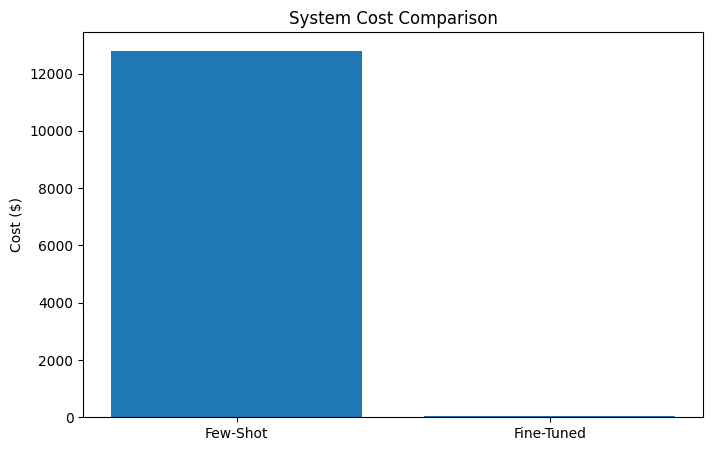

In [18]:
labels = [

    "Few-Shot",

    "Fine-Tuned"
]

costs = [

    few_shot_total,

    finetuned_total
]

plt.figure(figsize=(8, 5))

plt.bar(
    labels,
    costs
)

plt.ylabel("Cost ($)")

plt.title(
    "System Cost Comparison"
)

plt.show()

In [19]:
request_scales = [

    1_000,

    10_000,

    100_000,

    1_000_000,

    10_000_000
]

few_shot_scale_costs = []

finetuned_scale_costs = []

for requests in request_scales:

    few_cost = calculate_inference_cost(

        FEW_SHOT_INPUT_TOKENS,

        FEW_SHOT_OUTPUT_TOKENS,

        PRICING["gpt_4o"][
            "input_per_million"
        ],

        PRICING["gpt_4o"][
            "output_per_million"
        ],

        requests
    )["total_cost"]

    ft_cost = calculate_inference_cost(

        FINETUNED_INPUT_TOKENS,

        FINETUNED_OUTPUT_TOKENS,

        PRICING["gpt_4o_mini"][
            "input_per_million"
        ],

        PRICING["gpt_4o_mini"][
            "output_per_million"
        ],

        requests
    )["total_cost"]

    ft_cost += training_cost

    few_shot_scale_costs.append(
        few_cost
    )

    finetuned_scale_costs.append(
        ft_cost
    )

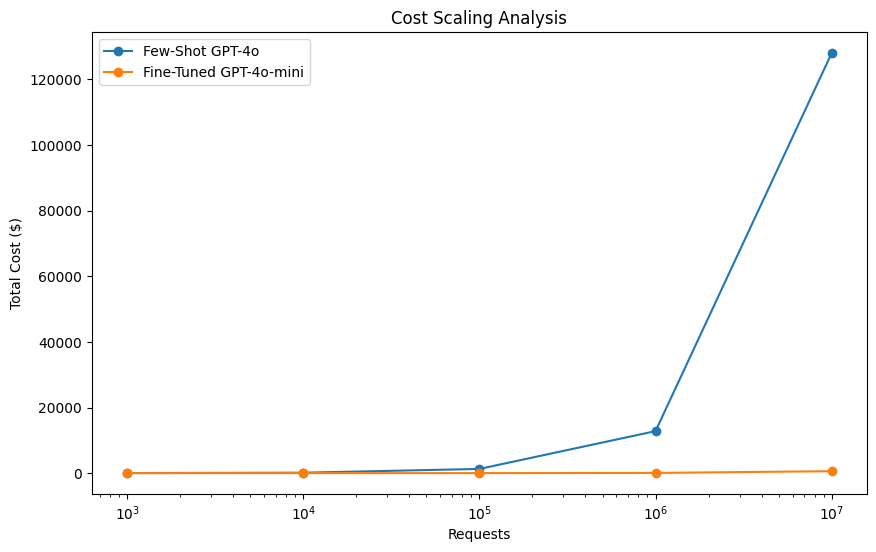

In [20]:
plt.figure(figsize=(10, 6))

plt.plot(
    request_scales,
    few_shot_scale_costs,
    marker="o",
    label="Few-Shot GPT-4o"
)

plt.plot(
    request_scales,
    finetuned_scale_costs,
    marker="o",
    label="Fine-Tuned GPT-4o-mini"
)

plt.xscale("log")

plt.xlabel("Requests")

plt.ylabel("Total Cost ($)")

plt.title(
    "Cost Scaling Analysis"
)

plt.legend()

plt.show()

In [21]:
roi = (
    absolute_savings
    /
    training_cost
) * 100

print("=" * 80)
print("ROI ANALYSIS")
print("=" * 80)

print(f"ROI: {roi:.2f}%")

ROI ANALYSIS
ROI: 1327061.46%


In [22]:
engineering_factors = pd.DataFrame([

    {

        "Challenge":
        "Training Infrastructure",

        "Impact":
        "GPU provisioning and orchestration"
    },

    {

        "Challenge":
        "Dataset Maintenance",

        "Impact":
        "Continuous curation and validation"
    },

    {

        "Challenge":
        "Evaluation Systems",

        "Impact":
        "Automated quality assurance"
    },

    {

        "Challenge":
        "Model Drift",

        "Impact":
        "Periodic retraining requirements"
    },

    {

        "Challenge":
        "Deployment Complexity",

        "Impact":
        "Model serving and rollback handling"
    }
])

engineering_factors

,Challenge,Impact
0,Training Infrastructure,GPU provisioning and orchestration
1,Dataset Maintenance,Continuous curation and validation
2,Evaluation Systems,Automated quality assurance
3,Model Drift,Periodic retraining requirements
4,Deployment Complexity,Model serving and rollback handling


In [23]:
opensource_challenges = [

    "GPU memory optimization",

    "QLoRA quantization complexity",

    "Checkpoint management",

    "Distributed training",

    "Inference optimization",

    "vLLM deployment",

    "CUDA compatibility",

    "Model merging",

    "Adapter versioning",

    "Serving latency optimization"
]

for item in opensource_challenges:

    print("-", item)

- GPU memory optimization
- QLoRA quantization complexity
- Checkpoint management
- Distributed training
- Inference optimization
- vLLM deployment
- CUDA compatibility
- Model merging
- Adapter versioning
- Serving latency optimization


In [24]:
versioning_challenges = [

    "Model lineage tracking",

    "Rollback mechanisms",

    "A/B deployment strategies",

    "Dataset version coupling",

    "Evaluation reproducibility",

    "Canary deployments",

    "Backward compatibility",

    "Evaluation drift monitoring",

    "Experiment tracking",

    "Inference consistency"
]

for item in versioning_challenges:

    print("-", item)

- Model lineage tracking
- Rollback mechanisms
- A/B deployment strategies
- Dataset version coupling
- Evaluation reproducibility
- Canary deployments
- Backward compatibility
- Evaluation drift monitoring
- Experiment tracking
- Inference consistency


In [25]:
print("=" * 80)
print("WHY SFT CANNOT TEACH NEW KNOWLEDGE")
print("=" * 80)

print("""
SFT primarily teaches:
- formatting
- response style
- behavioral alignment
- structural patterns

SFT does NOT fundamentally:
- retrain world knowledge
- deeply update reasoning capabilities
- reliably inject factual memory

Why?

Because:
- datasets are too small
- gradients are shallow
- pretrained priors dominate
- catastrophic forgetting risks exist

For new knowledge:
- RAG
- retrieval systems
- continual pretraining
- external memory

are usually better approaches.
""")

WHY SFT CANNOT TEACH NEW KNOWLEDGE

SFT primarily teaches:
- formatting
- response style
- behavioral alignment
- structural patterns

SFT does NOT fundamentally:
- retrain world knowledge
- deeply update reasoning capabilities
- reliably inject factual memory

Why?

Because:
- datasets are too small
- gradients are shallow
- pretrained priors dominate
- catastrophic forgetting risks exist

For new knowledge:
- RAG
- retrieval systems
- continual pretraining
- external memory

are usually better approaches.



In [26]:
print("=" * 80)
print("PHASE 3 FINAL REPORT")
print("=" * 80)

print()

print("1. AFTER HOW MANY REQUESTS IS FT PROFITABLE?")
print(
    int(break_even_requests)
)

print()

print("2. WHAT % COST REDUCTION WAS ACHIEVED?")
print(
    f"{percentage_savings:.2f}%"
)

print()

print("3. WHY IS FINE-TUNING POWERFUL?")
print("""
- reduces prompt bloat
- lowers inference cost
- improves deterministic outputs
- reduces latency
- scales efficiently
""")

print()

print("4. WHAT ARE THE TRADEOFFS?")
print("""
- upfront training cost
- dataset engineering complexity
- evaluation overhead
- retraining maintenance
- deployment management
""")

print()

print("5. WHAT DOES THIS LAB DEMONSTRATE?")
print("""
- production AI cost optimization
- LLMOps thinking
- ROI-driven AI engineering
- evaluation-centric workflows
- real-world model optimization strategy
""")

PHASE 3 FINAL REPORT

1. AFTER HOW MANY REQUESTS IS FT PROFITABLE?
75

2. WHAT % COST REDUCTION WAS ACHIEVED?
99.53%

3. WHY IS FINE-TUNING POWERFUL?

- reduces prompt bloat
- lowers inference cost
- improves deterministic outputs
- reduces latency
- scales efficiently


4. WHAT ARE THE TRADEOFFS?

- upfront training cost
- dataset engineering complexity
- evaluation overhead
- retraining maintenance
- deployment management


5. WHAT DOES THIS LAB DEMONSTRATE?

- production AI cost optimization
- LLMOps thinking
- ROI-driven AI engineering
- evaluation-centric workflows
- real-world model optimization strategy

